Kaggle Dataset

In [6]:
import pandas as pd

# Load Kaggle data
kaggle_path = "Sentiment_Stock_data.csv" 
kaggle_df = pd.read_csv(kaggle_path)

print(kaggle_df.head(5))
print(kaggle_df.columns)
print(kaggle_df['Sentiment'].value_counts())  
#Rename coloumns 
kaggle_df = kaggle_df.rename(columns={
    'Sentence': 'headline',
    'Sentiment': 'kaggle_sentiment'   # 0 or 1
})


   Unnamed: 0  Sentiment                                           Sentence
0           0          0  According to Gran , the company has no plans t...
1           1          1  For the last quarter of 2010 , Componenta 's n...
2           2          1  In the third quarter of 2010 , net sales incre...
3           3          1  Operating profit rose to EUR 13.1 mn from EUR ...
4           4          1  Operating profit totalled EUR 21.1 mn , up fro...
Index(['Unnamed: 0', 'Sentiment', 'Sentence'], dtype='object')
Sentiment
1    55725
0    53026
Name: count, dtype: int64


Validate FinBERT: Run FinBERT on a sample of Kaggle sentences → compare predicted sentiment vs ground-truth 0/1 labels.

In [9]:
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# Load Kaggle
kaggle = pd.read_csv("Sentiment_Stock_data.csv")  # adjust path/filename
kaggle = kaggle.rename(columns={'Sentence': 'headline', 'Sentiment': 'true_label'})

# Take larger sample (e.g. 300–500)
sample = kaggle.sample(n=300, random_state=42)  # adjust n

# FinBERT pipeline
finbert = pipeline("sentiment-analysis", model="ProsusAI/finbert")

# Predict
def finbert_predict(text):
    result = finbert(text[:512])[0]
    if result['label'] == 'positive':
        return 1
    else:
        return 0  # negative or neutral → 0

sample['finbert_pred'] = sample['headline'].apply(finbert_predict)

# Results
accuracy = (sample['true_label'] == sample['finbert_pred']).mean()
print(f"FinBERT agreement on {len(sample)} sentences: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(sample['true_label'], sample['finbert_pred']))

print("\nConfusion Matrix:")
print(confusion_matrix(sample['true_label'], sample['finbert_pred']))

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 21791.69it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT agreement on 300 sentences: 53.67%

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.91      0.68       161
           1       0.50      0.11      0.18       139

    accuracy                           0.54       300
   macro avg       0.52      0.51      0.43       300
weighted avg       0.52      0.54      0.45       300


Confusion Matrix:
[[146  15]
 [124  15]]


In [10]:
sample.to_csv("kaggle_finbert_validation.csv", index=False)
print("Validation results saved.")

Validation results saved.


NVDA Sentiment

In [13]:
import yfinance as yf
import pandas as pd

nvda = yf.Ticker("NVDA")
news = nvda.news

# Extract nested content
extracted = []
for item in news:
    if 'content' in item:
        cont = item['content']
        extracted.append({
            'id': item.get('id'),
            'title': cont.get('title'),
            'pubDate': cont.get('pubDate'),
            'displayTime': cont.get('displayTime'),
            'publisher': cont.get('provider', {}).get('displayName'),
            'link': cont.get('canonicalUrl', {}).get('url'),
            'description': cont.get('summary') or cont.get('description'),
            'thumbnail': cont.get('thumbnail', {}).get('originalUrl')
        })

news_df = pd.DataFrame(extracted)

# Convert date/time
if 'pubDate' in news_df.columns:
    news_df['datetime'] = pd.to_datetime(news_df['pubDate'], errors='coerce')
    news_df['date'] = news_df['datetime'].dt.date

# Sort recent first
news_df = news_df.sort_values('datetime', ascending=False)

print(f"Extracted {len(news_df)} news items")
print(news_df.head(8))  # show first few
print("\nColumns now:", news_df.columns.tolist())

Extracted 10 news items
                                     id  \
4  4b916efc-2c36-3979-b005-e9c61664c5e0   
5  bf067c88-b354-3c65-9ad7-6becdf149245   
6  9f2c65db-79bf-389a-822b-dd2347221fd9   
7  3700e802-5a8d-3ad0-af7b-f83e2f832d8e   
8  84bedf05-3000-3222-8a01-b42ecf6766af   
9  380f27ba-9c9a-3279-881b-b442328e5ecb   
1  5e43bc32-ca5a-3b88-9be3-216fcf4c1f39   
2  12672c56-156c-315f-b1c7-cc045c4d8221   

                                               title               pubDate  \
4  VOO vs. SPY vs. IVV: The One Factor That Sets ...  2026-03-18T14:05:00Z   
5       The Top 2 Industrial Stocks to Buy Right Now  2026-03-18T13:58:00Z   
6  I Used to Think Medicare Advantage Was the Bes...  2026-03-18T13:56:00Z   
7  Why I Wouldn't Touch Tilray Brands Stock With ...  2026-03-18T13:35:00Z   
8  Micron Earnings Face High Expectations as Its ...  2026-03-18T13:34:21Z   
9  What NVDA Investors Need To Know About Nvidia'...  2026-03-18T13:31:06Z   
1  Nvidia to power Uber's autonomous fleet

FinBERT Sentiment Code

In [14]:
from transformers import pipeline

sentiment_pipeline = pipeline("sentiment-analysis", model="ProsusAI/finbert")

def get_sentiment(text):
    if pd.isna(text) or not text:
        return 0.0
    result = sentiment_pipeline(text[:512])[0]
    if result['label'] == 'positive':
        return result['score']
    elif result['label'] == 'negative':
        return -result['score']
    return 0.0

news_df['finbert_sentiment'] = news_df['title'].apply(get_sentiment)

print(news_df[['date', 'title', 'finbert_sentiment']].head(10))

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 25624.78it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


         date                                              title  \
4  2026-03-18  VOO vs. SPY vs. IVV: The One Factor That Sets ...   
5  2026-03-18       The Top 2 Industrial Stocks to Buy Right Now   
6  2026-03-18  I Used to Think Medicare Advantage Was the Bes...   
7  2026-03-18  Why I Wouldn't Touch Tilray Brands Stock With ...   
8  2026-03-18  Micron Earnings Face High Expectations as Its ...   
9  2026-03-18  What NVDA Investors Need To Know About Nvidia'...   
1  2026-03-17  Nvidia to power Uber's autonomous fleet in new...   
2  2026-03-17  Nvidia to power Uber autonomous cars, Oklo's n...   
3  2026-03-17  Nvidia GTC: Why Dan Ives says it's impossible ...   
0  2026-03-13  Tech stocks today: Microsoft shakes up AI lead...   

   finbert_sentiment  
4           0.000000  
5           0.000000  
6           0.000000  
7           0.000000  
8           0.925643  
9           0.000000  
1           0.000000  
2           0.000000  
3           0.000000  
0          -0.736447 

Aggregate daily (mean sentiment per day)

In [15]:
daily_sentiment = news_df.groupby('date')['finbert_sentiment'].mean().reset_index()
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'])
print(daily_sentiment)

        date  finbert_sentiment
0 2026-03-13          -0.736447
1 2026-03-17           0.000000
2 2026-03-18           0.154274


Merging the daily FinBERT sentiment scores with existing NVDA price data

In [38]:
# ────────────────────────────────────────────────────────────────
# QUICK FINBERT VALIDATION ON KAGGLE DATASET
# ────────────────────────────────────────────────────────────────

import torch                               # ← ADD THIS LINE HERE
from transformers import pipeline
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

# 1. Load or use your Kaggle data (adjust path/columns if needed)
kaggle = pd.read_csv("Sentiment_Stock_data.csv") 

# 2. Take a larger random sample
n_samples = 400
sample = kaggle.sample(n=n_samples, random_state=42).copy()

print(f"Validating FinBERT on {len(sample)} random sentences...")

# 3. Load FinBERT pipeline
device = 0 if torch.cuda.is_available() else -1
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert",
    device=device
)

# 4. Predict function (0 = negative/neutral, 1 = positive)
def finbert_predict(text):
    if pd.isna(text) or not text.strip():
        return 0
    result = sentiment_pipeline(text[:512])[0]
    return 1 if result['label'] == 'positive' else 0

# Apply prediction
sample['finbert_pred'] = sample['Sentence'].apply(finbert_predict)

# 5. Results
accuracy = (sample['Sentiment'] == sample['finbert_pred']).mean()
print(f"\nFinBERT zero-shot agreement: {accuracy:.2%}")

print("\nClassification Report:")
print(classification_report(
    sample['Sentiment'],
    sample['finbert_pred'],
    target_names=['Negative/Neutral (0)', 'Positive (1)'],
    digits=3
))

print("\nConfusion Matrix:")
print(confusion_matrix(sample['Sentiment'], sample['finbert_pred']))

# 6. Save results
sample.to_csv("kaggle_finbert_validation_results.csv", index=False)
print("Results saved.")

Validating FinBERT on 400 random sentences...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 11990.88it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



FinBERT zero-shot agreement: 53.50%

Classification Report:
                      precision    recall  f1-score   support

Negative/Neutral (0)      0.538     0.930     0.682       214
        Positive (1)      0.500     0.081     0.139       186

            accuracy                          0.535       400
           macro avg      0.519     0.505     0.410       400
        weighted avg      0.520     0.535     0.429       400


Confusion Matrix:
[[199  15]
 [171  15]]
Results saved.


NVDA-specific sentiment feature using FinBERT on real news headlines

In [39]:
import yfinance as yf
import pandas as pd

# Fetch NVDA news
nvda = yf.Ticker("NVDA")
news = nvda.news

print("Number of news items:", len(news))
if news:
    print("First item keys:", list(news[0].keys()))
    print("First item content keys:", list(news[0].get('content', {}).keys()))
    
extracted = []
for item in news:
    if 'content' in item:
        c = item['content']
        extracted.append({
            'title': c.get('title', ''),
            'pubDate': c.get('pubDate', ''),
            'publisher': c.get('provider', {}).get('displayName', ''),
            'link': c.get('canonicalUrl', {}).get('url', ''),
            'summary': c.get('summary', '')
        })

news_df = pd.DataFrame(extracted)

# Convert pubDate to datetime
if 'pubDate' in news_df.columns:
    news_df['datetime'] = pd.to_datetime(news_df['pubDate'], errors='coerce', utc=True)
    news_df['date'] = news_df['datetime'].dt.date

news_df = news_df.sort_values('datetime', ascending=False).reset_index(drop=True)

print(news_df[['date', 'title', 'publisher']].head(10))
print(f"\nTotal headlines extracted: {len(news_df)}")

Number of news items: 10
First item keys: ['id', 'content']
First item content keys: ['id', 'contentType', 'title', 'description', 'summary', 'pubDate', 'displayTime', 'isHosted', 'bypassModal', 'previewUrl', 'thumbnail', 'provider', 'canonicalUrl', 'clickThroughUrl', 'metadata', 'finance', 'storyline']
         date                                              title  \
0  2026-03-18        Nvidia May Be Signaling AI's Next Big Shift   
1  2026-03-18             Nvidia May Be Slipping Back Into China   
2  2026-03-18  1 Can't-Miss Artificial Intelligence (AI) Stoc...   
3  2026-03-18  The Trump Administration Just Rewarded Archer ...   
4  2026-03-18           4 Dividend Energy Stocks to Buy in March   
5  2026-03-18  Applied Optoelectronics Rises 7% — NVIDIA’s AI...   
6  2026-03-18  Why Your S&P 500 ETF Could Rapidly Include SpaceX   
7  2026-03-17  Nvidia CEO Huang says company sees more than $...   
8  2026-03-17  Is there still upside for Microsoft after stoc...   
9  2026-03-13  

Run FinBERT sentiment on titles

In [40]:
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1
sentiment_pipe = pipeline("sentiment-analysis", model="ProsusAI/finbert", device=device)

def get_sentiment(text):
    if not text or pd.isna(text):
        return 0.0
    result = sentiment_pipe(text[:512])[0]
    if result['label'] == 'positive':
        return result['score']
    elif result['label'] == 'negative':
        return -result['score']
    return 0.0

news_df['finbert_sentiment'] = news_df['title'].apply(get_sentiment)

print(news_df[['date', 'title', 'finbert_sentiment']].head(10))

daily_sentiment = news_df.groupby('date')['finbert_sentiment'].mean().reset_index()
daily_sentiment['date'] = pd.to_datetime(daily_sentiment['date'])

print("Daily sentiment scores:")
print(daily_sentiment)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 21599.63it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


         date                                              title  \
0  2026-03-18        Nvidia May Be Signaling AI's Next Big Shift   
1  2026-03-18             Nvidia May Be Slipping Back Into China   
2  2026-03-18  1 Can't-Miss Artificial Intelligence (AI) Stoc...   
3  2026-03-18  The Trump Administration Just Rewarded Archer ...   
4  2026-03-18           4 Dividend Energy Stocks to Buy in March   
5  2026-03-18  Applied Optoelectronics Rises 7% — NVIDIA’s AI...   
6  2026-03-18  Why Your S&P 500 ETF Could Rapidly Include SpaceX   
7  2026-03-17  Nvidia CEO Huang says company sees more than $...   
8  2026-03-17  Is there still upside for Microsoft after stoc...   
9  2026-03-13  Tech stocks today: Microsoft shakes up AI lead...   

   finbert_sentiment  
0           0.000000  
1          -0.958692  
2           0.000000  
3           0.000000  
4           0.000000  
5          -0.604204  
6           0.000000  
7           0.700807  
8          -0.918900  
9          -0.736447 

Saving results and Plotting

Merged data saved. Preview:
                 Close  finbert_sentiment
Date                                     
2026-02-25  195.549408           0.000000
2026-02-26  184.879990           0.000000
2026-02-27  177.180420           0.000000
2026-03-02  182.470123           0.000000
2026-03-03  180.040253           0.000000
2026-03-04  183.030090           0.000000
2026-03-05  183.330078           0.000000
2026-03-06  177.810379           0.000000
2026-03-09  182.640106           0.000000
2026-03-10  184.760010           0.000000
2026-03-11  186.029999           0.000000
2026-03-12  183.139999           0.000000
2026-03-13  180.250000          -0.736447
2026-03-16  183.220001           0.000000
2026-03-17  181.929993          -0.109047


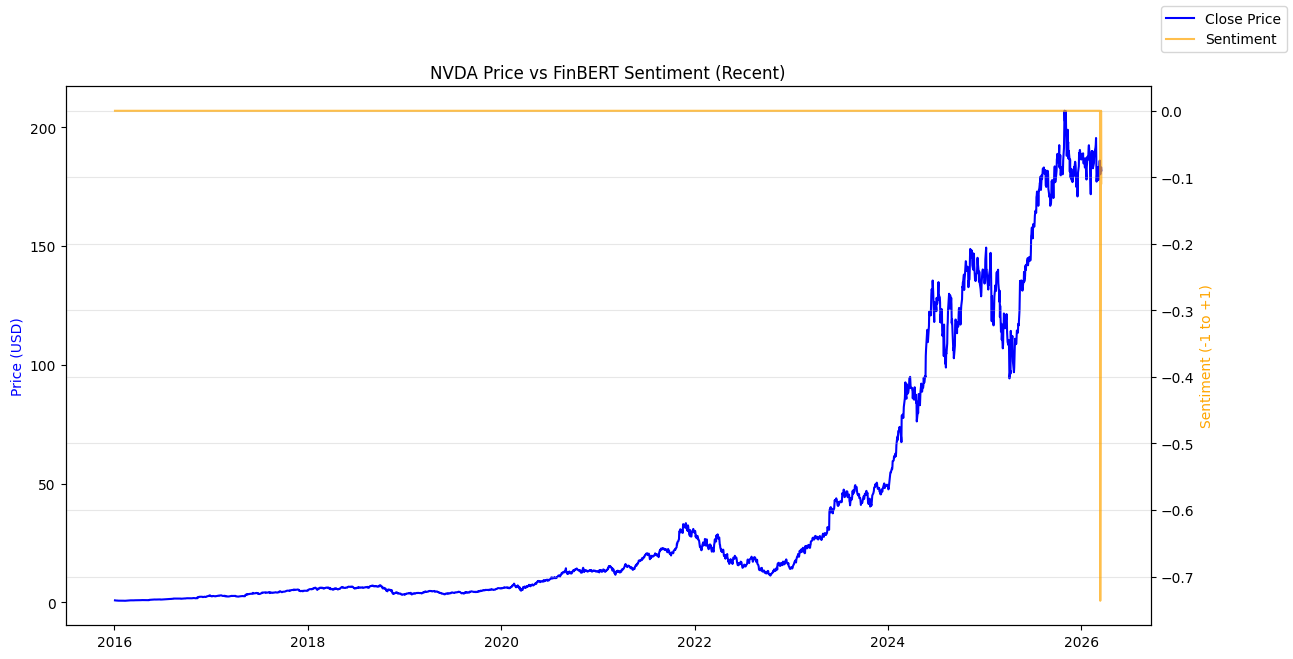

In [42]:
prices = pd.read_csv("nvda_prices.csv", index_col="Date", parse_dates=True, dayfirst=True)

prices_reset = prices.reset_index()

merged = prices_reset.merge(
    daily_sentiment,
    left_on=prices_reset['Date'].dt.date,
    right_on=daily_sentiment['date'].dt.date,
    how='left'
)

merged = merged.drop(columns=['date'])
merged['finbert_sentiment'] = merged['finbert_sentiment'].fillna(0)

merged = merged.set_index('Date')

merged.to_csv("nvda_prices_with_sentiment.csv")

print("Merged data saved. Preview:")
print(merged[['Close', 'finbert_sentiment']].tail(15))

import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(14,7))

ax1.plot(merged.index, merged['Close'], color='blue', label='Close Price')
ax1.set_ylabel('Price (USD)', color='blue')

ax2 = ax1.twinx()
ax2.plot(merged.index, merged['finbert_sentiment'], color='orange', label='Sentiment', alpha=0.7)
ax2.set_ylabel('Sentiment (-1 to +1)', color='orange')

plt.title('NVDA Price vs FinBERT Sentiment (Recent)')
plt.grid(True, alpha=0.3)
fig.legend()
plt.show()